# Practical 1: ECG Heartbeat Classification (PTB-DB)

## 1. Setup & Load Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = '/content/drive/MyDrive/MLMed Dataset/Lab 1/Data_1/'

df_normal = pd.read_csv(DATA_DIR + 'ptbdb_normal.csv', header=None)
df_abnormal = pd.read_csv(DATA_DIR + 'ptbdb_abnormal.csv', header=None)

print('Normal shape:', df_normal.shape)
print('Abnormal shape:', df_abnormal.shape)

Normal shape: (4046, 188)
Abnormal shape: (10506, 188)


## 2. Preprocessing

In [3]:
df_normal.iloc[:, -1] = 0
df_abnormal.iloc[:, -1] = 1

df_all = pd.concat([df_normal, df_abnormal], axis=0, ignore_index=True)
df_all = df_all.sample(frac=1, random_state=101).reset_index(drop=True)

print('Total samples:', df_all.shape[0])
print('Features:', df_all.shape[1] - 1)

Total samples: 14552
Features: 187


In [4]:
print(df_all.describe())
print('\nMissing values:', df_all.isnull().sum().sum())

                0             1             2             3             4    \
count  14552.000000  14552.000000  14552.000000  14552.000000  14552.000000   
mean       0.976637      0.721663      0.403099      0.242893      0.207218   
std        0.034532      0.195690      0.249794      0.249519      0.218097   
min        0.624227      0.000000      0.000000      0.000000      0.000000   
25%        0.959377      0.584589      0.212300      0.052269      0.061875   
50%        1.000000      0.740148      0.371911      0.168148      0.136082   
75%        1.000000      0.881483      0.557785      0.336232      0.264104   
max        1.000000      1.000000      1.000000      1.000000      1.000000   

                5             6             7             8             9    \
count  14552.000000  14552.000000  14552.000000  14552.000000  14552.000000   
mean       0.216453      0.221752      0.224486      0.227349      0.229704   
std        0.192412      0.180740      0.176943    

## 3. EDA

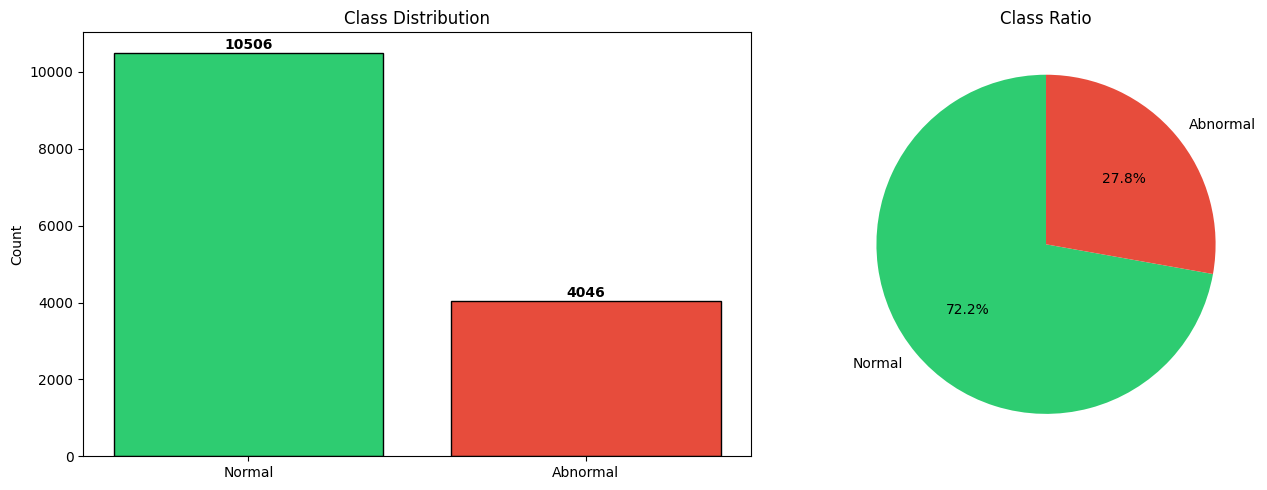

In [5]:
label_counts = df_all.iloc[:, -1].value_counts()
labels_text = ['Normal', 'Abnormal']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(labels_text, label_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=labels_text, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Class Ratio')

plt.tight_layout()
plt.show()

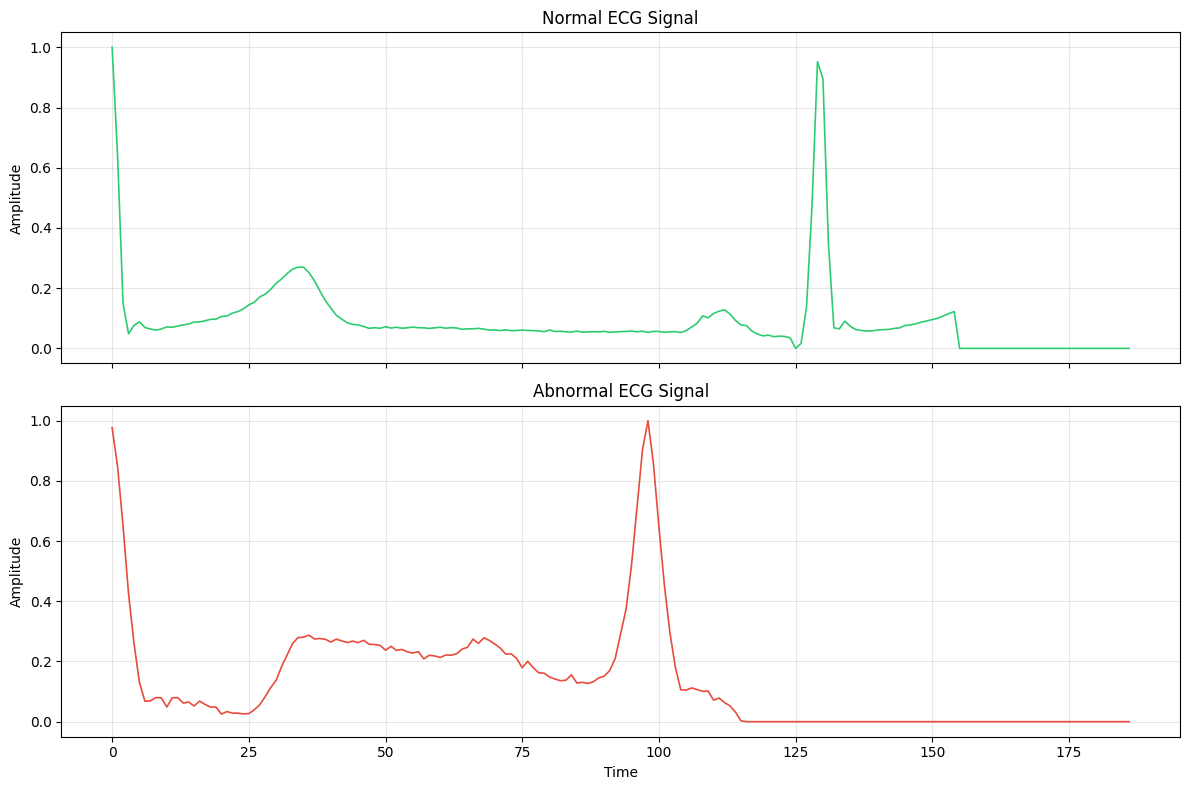

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ecg_normal_sample = df_all[df_all.iloc[:, -1] == 0].iloc[5, :-1]
ecg_abnormal_sample = df_all[df_all.iloc[:, -1] == 1].iloc[5, :-1]

axes[0].plot(ecg_normal_sample.values, color='#2ecc71', linewidth=1.2)
axes[0].set_title('Normal ECG Signal')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ecg_abnormal_sample.values, color='#e74c3c', linewidth=1.2)
axes[1].set_title('Abnormal ECG Signal')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

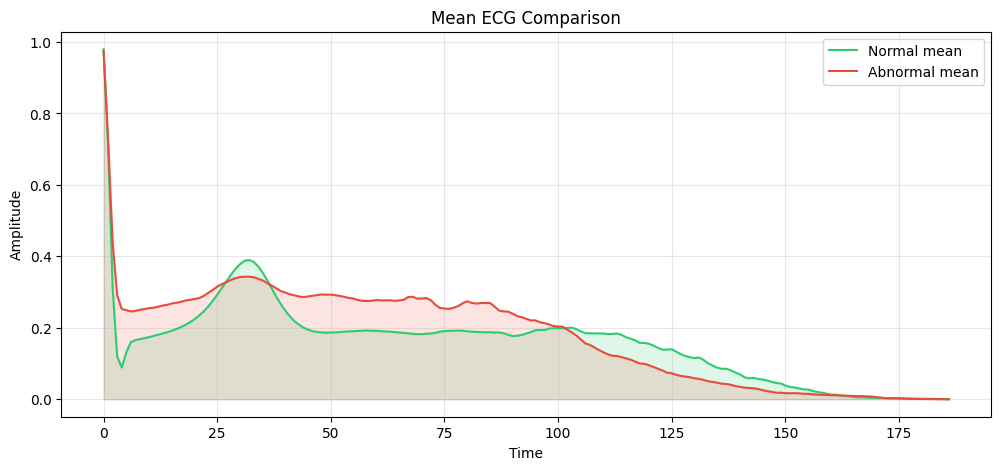

In [7]:
avg_normal = df_all[df_all.iloc[:, -1] == 0].iloc[:, :-1].mean(axis=0)
avg_abnormal = df_all[df_all.iloc[:, -1] == 1].iloc[:, :-1].mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(avg_normal.values, label='Normal mean', color='#2ecc71', linewidth=1.5)
plt.plot(avg_abnormal.values, label='Abnormal mean', color='#e74c3c', linewidth=1.5)
plt.fill_between(range(len(avg_normal)), avg_normal.values, alpha=0.15, color='#2ecc71')
plt.fill_between(range(len(avg_abnormal)), avg_abnormal.values, alpha=0.15, color='#e74c3c')
plt.title('Mean ECG Comparison')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Train/Test Split

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

features = df_all.iloc[:, :-1].values
labels = df_all.iloc[:, -1].values.astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    features, labels, test_size=0.2, random_state=101, stratify=labels
)

X_tr = X_tr[..., np.newaxis]
X_te = X_te[..., np.newaxis]

print('Train:', X_tr.shape, y_tr.shape)
print('Test:', X_te.shape, y_te.shape)

Train: (11641, 187, 1) (11641,)
Test: (2911, 187, 1) (2911,)


In [9]:
cls_labels = np.array([0, 1])
w = compute_class_weight(class_weight='balanced', classes=cls_labels, y=y_tr)
cw = {0: w[0], 1: w[1]}
print('Class weights:', cw)

Class weights: {0: np.float64(1.7981155390793946), 1: np.float64(0.6925868633983817)}


## 5. Build CNN Model

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(101)

def build_ecg_model(input_shape=(187, 1)):
    mdl = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(16, kernel_size=5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(32, kernel_size=5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return mdl

ecg_model = build_ecg_model()

ecg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

ecg_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 93, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1472)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       188,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,049 (789.25 KB)

 Trainable params: 201,825 (788.38 KB)

 Non-trainable params: 224 (896.00 B)

## 6. Training

In [11]:
cb_list = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=7, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    )
]

train_history = ecg_model.fit(
    X_tr, y_tr,
    validation_split=0.15,
    epochs=25,
    batch_size=64,
    class_weight=cw,
    callbacks=cb_list,
    verbose=1
)

Epoch 1/25
155/155 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.8050 - auc: 0.8958 - loss: 0.4083 - precision: 0.9261 - recall: 0.7932 - val_accuracy: 0.6955 - val_auc: 0.6647 - val_loss: 0.6141 - val_precision: 0.7208 - val_recall: 0.9437 - learning_rate: 5.0000e-04
Epoch 2/25
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9088 - auc: 0.9707 - loss: 0.2195 - precision: 0.9648 - recall: 0.9068 - val_accuracy: 0.6903 - val_auc: 0.7287 - val_loss: 0.5352 - val_precision: 0.7560 - val_recall: 0.8430 - learning_rate: 5.0000e-04
Epoch 3/25
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9356 - auc: 0.9837 - loss: 0.1632 - precision: 0.9760 - recall: 0.9338 - val_accuracy: 0.7945 - val_auc: 0.8741 - val_loss: 0.4280 - val_precision: 0.8003 - val_recall: 0.9532 - learning_rate: 5.0000e-04
Epoch 4/25
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9590 - auc: 0.9917 - loss: 0.1142 - precision: 0.9850 - recall: 0.9577 - val_accuracy: 0.9118 - val_auc: 0.9708 - val_loss

## 7. Evaluation

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

y_pred_prob = ecg_model.predict(X_te).ravel()
y_pred_cls = (y_pred_prob >= 0.5).astype(int)

print('=== Classification Report ===')
print(classification_report(y_te, y_pred_cls, target_names=['Normal', 'Abnormal']))

cm = confusion_matrix(y_te, y_pred_cls)
print('=== Confusion Matrix ===')
print(cm)

91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99       809
    Abnormal       1.00      0.99      0.99      2102

    accuracy                           0.99      2911
   macro avg       0.99      0.99      0.99      2911
weighted avg       0.99      0.99      0.99      2911

=== Confusion Matrix ===
[[ 799   10]
 [  13 2089]]


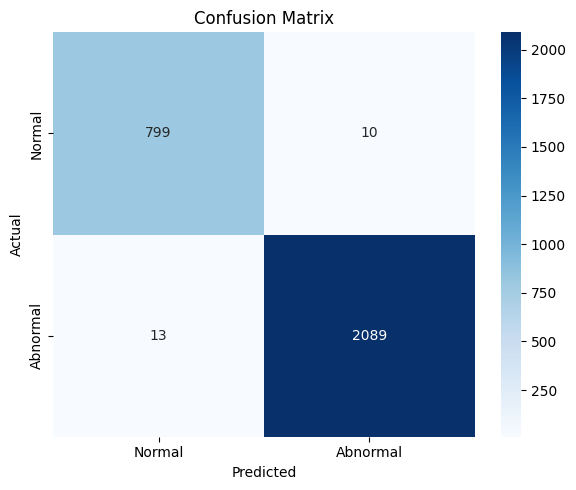

In [13]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

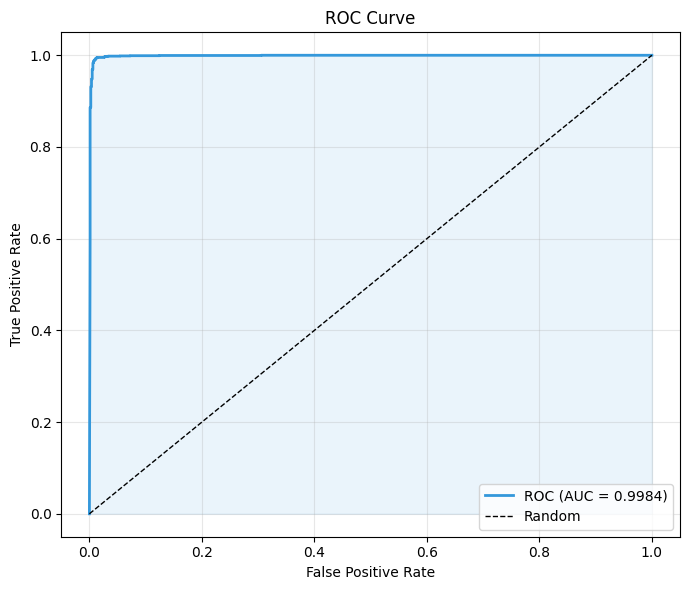

In [14]:
fpr_vals, tpr_vals, _ = roc_curve(y_te, y_pred_prob)
auc_val = roc_auc_score(y_te, y_pred_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr_vals, tpr_vals, color='#3498db', linewidth=2,
         label=f'ROC (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.fill_between(fpr_vals, tpr_vals, alpha=0.1, color='#3498db')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

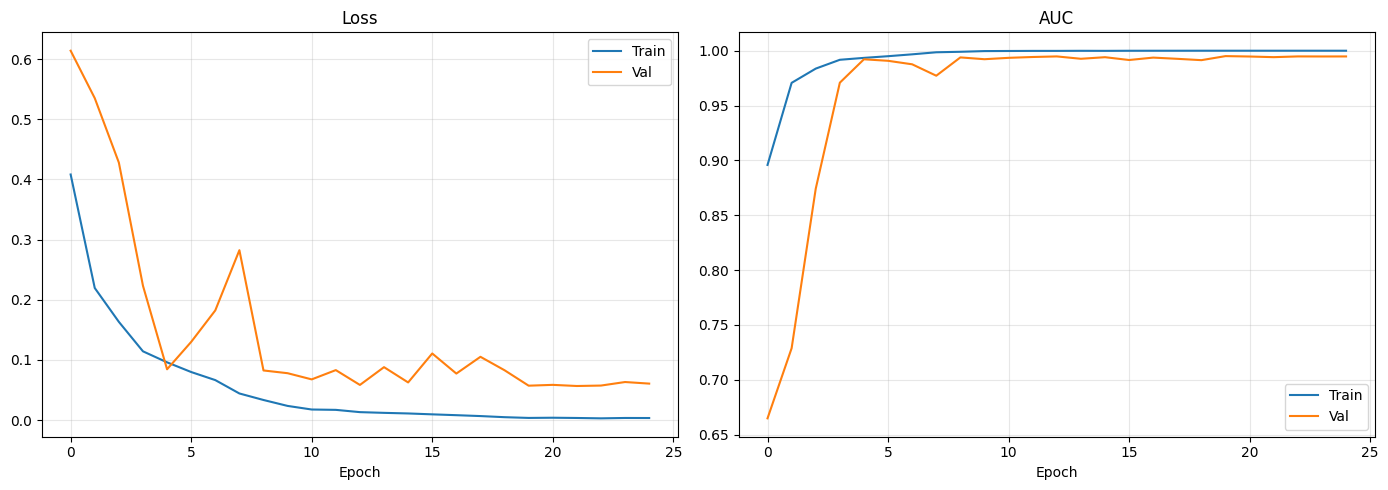

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_history.history['loss'], label='Train')
axes[0].plot(train_history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_history.history['auc'], label='Train')
axes[1].plot(train_history.history['val_auc'], label='Val')
axes[1].set_title('AUC')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()